# Quick start guide

This notebook provides minimal code snippets to illustrate the main functionlity of `SNuDD`.

In [4]:
%load_ext autoreload
%autoreload 2

import numpy
import matplotlib.pyplot as plt

## 1. Define an NSI model

The `GeneralNSI` class let's the user define an NSI model via the 3x3 Hermitian matrix of NSI magnitudes, $\varepsilon_{\alpha\beta}^{\eta,\varphi}$, and the relative strength of the NSI with electrons, protons and neutrons via the angles $\eta$ and $\varphi$.

In [27]:
from snudd.models import SM, GeneralNSI

# Define NSI parameters
NSI_matrix = numpy.array([[0.0, 0.0, 0.0],
                          [0.0, 0.0, 0.1],
                          [0.0, 0.1, 0.0]])
NSI_eta = numpy.pi/4
NSI_phi = 0

# Create NSI model object
NSI_model = GeneralNSI(NSI_matrix, NSI_eta, NSI_phi)
# NSI_model = SM() # <- Uncomment this line to use the SM instead

## 2. Compute neutrino density matrix

### Only solar density matrix

In [28]:
from snudd.nsi.nsi_probabilities import DensityMatrixCalculator

# Create probability calculator 
NSI_density_calculator = DensityMatrixCalculator(NSI_model)

# Calculate solar density matrix over neutrino energy range
Enus = numpy.geomspace(1e-6, 1e0, 200) # in GeV
solar_density = NSI_density_calculator.density(Enus, '8B')

# Returns an array of 3x3 density matrices evaluated over the Enus
numpy.shape(solar_density)

(200, 3, 3)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

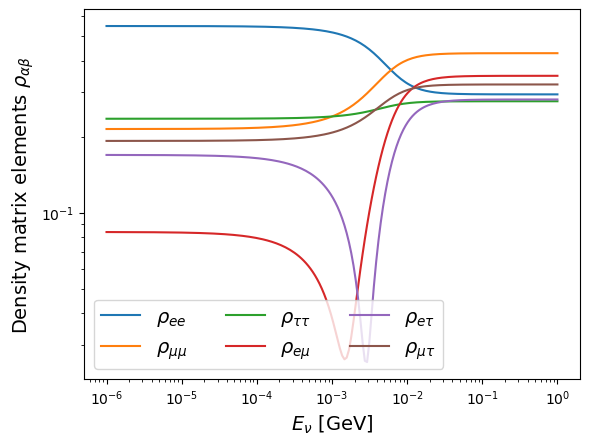

In [29]:
plt.loglog(Enus, abs(solar_density[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(Enus, abs(solar_density[:, 1,1]),  label=r'$\rho_{\mu\mu}$')
plt.loglog(Enus, abs(solar_density[:, 2,2]),  label=r'$\rho_{\tau\tau}$')
plt.loglog(Enus, abs(solar_density[:, 0,1]),  label=r'$\rho_{e\mu}$')
plt.loglog(Enus, abs(solar_density[:, 0,2]),  label=r'$\rho_{e\tau}$')
plt.loglog(Enus, abs(solar_density[:, 1,2]),  label=r'$\rho_{\mu\tau}$')

plt.legend(fontsize=14, ncol=3)

plt.ylabel(r'Density matrix elements $\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## 3. Include earth-matter effects

### Generate histogram of incident angles

In [30]:
from snudd.geometry import SolarAngles

# Define experimental parameters (location, data taking period)
lat_gs = 42.47  # Latitude of Gran Sasso in degrees north
t0     = 0      # t0 - beginning in days after 3rd January (perihelion)
T      = 365    # T  - duration of data taking in days

# Define solar angles calculator for Gran Sasso
GranSasso = SolarAngles(latitude=lat_gs, t0=t0, T=T)

# Generate histogram of cos(nadir) 
cnadirs, weights = GranSasso.cnadir_hist(bins=30)

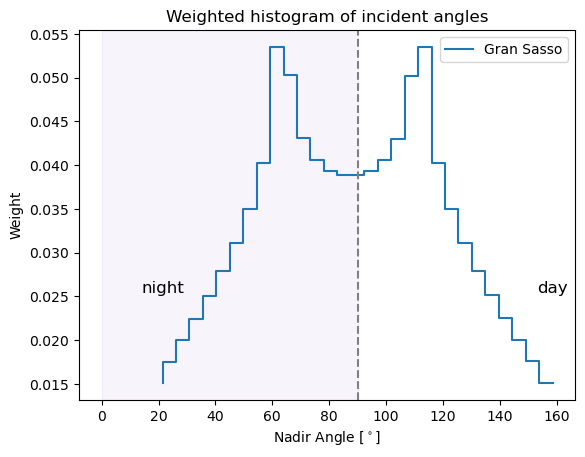

In [31]:
# Plot the weighted histogram of nadir angles
nadirs_gs = numpy.arccos(cnadirs) * 180 / numpy.pi  # Convert cnadirs to nadir angles in degrees


plt.step(nadirs_gs, weights, label='Gran Sasso')
plt.axvline(90, ls='--', color='gray')
plt.axvspan(0, 90, color='#792BB1', alpha=0.05)
plt.text(min(nadirs_gs), max(weights)/2, 'night', ha='center', va='top', size='large')
plt.text(max(nadirs_gs), max(weights)/2, 'day', ha='center', va='top', size='large')
plt.xlabel(r'Nadir Angle [$^\circ$]')
plt.ylabel('Weight')
plt.title("Weighted histogram of incident angles")
plt.legend()

### Combined solar + earth matter density matrix @ Gran Sasso

In [32]:
# Calculate full density matrix over neutrino energy range
Enus = numpy.geomspace(1e-6, 1e0, 200) # in GeV
earth_density = NSI_density_calculator.density_earth(Enus, cnadirs, weights, nu='8B')

# Returns an array of 3x3 denisty matrices evaluated over the Enus
numpy.shape(earth_density)

(200, 3, 3)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

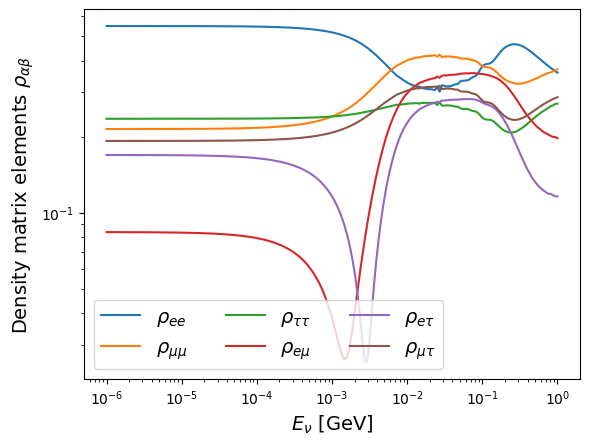

In [33]:
plt.loglog(Enus, abs(earth_density[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(Enus, abs(earth_density[:, 1,1]),  label=r'$\rho_{\mu\mu}$')
plt.loglog(Enus, abs(earth_density[:, 2,2]),  label=r'$\rho_{\tau\tau}$')
plt.loglog(Enus, abs(earth_density[:, 0,1]),  label=r'$\rho_{e\mu}$')
plt.loglog(Enus, abs(earth_density[:, 0,2]),  label=r'$\rho_{e\tau}$')
plt.loglog(Enus, abs(earth_density[:, 1,2]),  label=r'$\rho_{\mu\tau}$')

plt.legend(fontsize=14, ncol=3)

plt.ylabel(r'Density matrix elements $\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## 4. Computing the neutrino recoil spectrum

### 4.a Nuclear recoil spectrum

In [34]:
from snudd import config
from snudd.targets import Nucleus

# Create scattering target
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # single isotope 

# Load NSI model in scattering target and generate denisty matrix
Xe_nucleus.update_model(NSI_model)
Xe_nucleus.prepare_density() 
# Xe_nucleus.prepare_density(cnadirs=cnadirs, cnadir_weights=weights) # <- Uncomment to include earth matter effects @ Gran Sasso

# Compute recoil spectrum
E_Rs = numpy.geomspace(1e-2, 1e2, 500) / 1e6  # Recoil Energy in GeV
NSI_spec_nr = Xe_nucleus.spectrum(E_Rs)

Text(0.5, 0, '$E_{R}\\,\\,\\left[{\\rm keV}\\right]$')

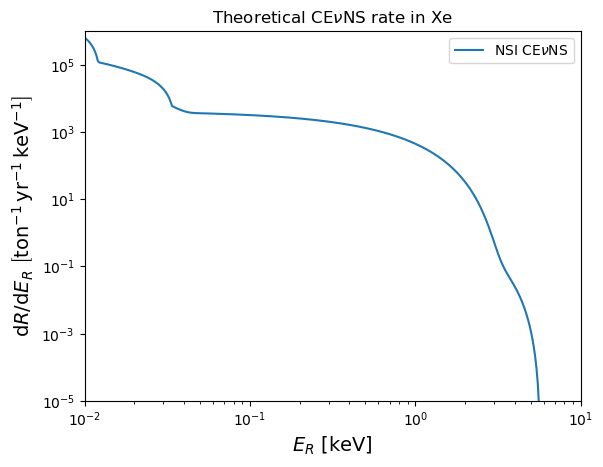

In [13]:
E_Rs_keV = E_Rs * 1e6 # Recoil Energy in keV for plotting
plt.loglog(E_Rs_keV, NSI_spec_nr, label=r"NSI CE$\nu$NS") 

plt.xlim(xmin=1e-2, xmax=1e1)
plt.ylim(ymax=1e6, ymin=1e-5)

plt.legend()
plt.title(r"Theoretical CE$\nu$NS rate in Xe")
plt.ylabel(r'${\rm d}R/{\rm d}E_R\,\,\left[{\rm ton}^{-1}\,{\rm yr}^{-1}\,{\rm keV}^{-1}\right]$', size=14)
plt.xlabel(r'$E_{R}\,\,\left[{\rm keV}\right]$', size=14)

### 4.b Electron recoil spectrum

In [35]:
from snudd import config
from snudd.targets import Nucleus, Electron   # still requires the host nucleus
from snudd.binding import binding_xe          # dataclass of binding energy data of xenon 
from snudd.rrpa    import rrpa_scaling        # ad-hoc rrpa scaling for bound electron

# Create host nucleus
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # single isotope 

# Create bound electron object
Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(NSI_model)
Xe_electron.prepare_density()
# Xe_nucleus.prepare_density(cnadirs=cnadirs, cnadir_weights=weights) # Uncomment to include earth matter effects @ Gran Sasso

# Compute recoil spectrum
E_Rs = numpy.geomspace(1e-2, 1e2, 500) / 1e6  # Recoil Energy in GeV
NSI_spec_er = Xe_electron.spectrum(E_Rs)

Text(0.5, 0, '$E_{R}\\,\\,\\left[{\\rm keV}\\right]$')

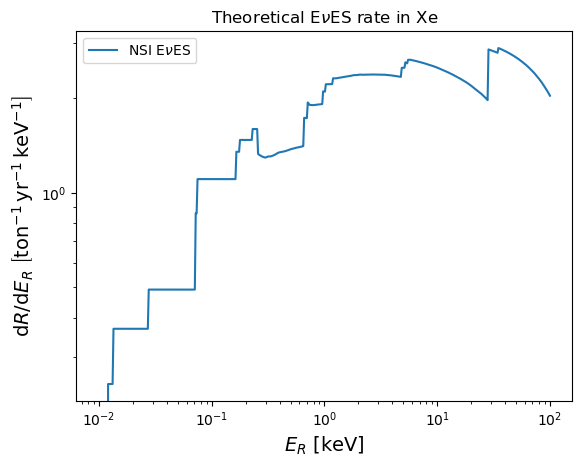

In [36]:
E_Rs_keV = E_Rs * 1e6 # Recoil Energy in keV for plotting
plt.loglog(E_Rs_keV, NSI_spec_er, label=r"NSI E$\nu$ES")


plt.legend()
plt.title(r"Theoretical E$\nu$ES rate in Xe")
plt.ylabel(r'${\rm d}R/{\rm d}E_R\,\,\left[{\rm ton}^{-1}\,{\rm yr}^{-1}\,{\rm keV}^{-1}\right]$', size=14)
plt.xlabel(r'$E_{R}\,\,\left[{\rm keV}\right]$', size=14)

## 5. Including detector effects

Here we deomnstrate how to compute a reconstruction-level binned histogram of solar neutrino-induced electron recoil events for a future xenon experiment like XLZD or PandaX-xT with an exposure of $\epsilon = 200$ tonne-years. To get a realistic prediction of the events, we employ the current LZ efficiency function and energy resolution.

In [ ]:
from snudd.efficiencies import efficiency_lz_er_WS24
from snudd.resolution   import res_lz_er
from snudd.resolution   import Convolver

# Counts @ future xenon detector
def counts_future_xe(specturm, E_Rs, E1, E2):
    exposure_future = 200. # t yrs
    convolution_lz_sig = Convolver(E_Rs, specturm, efficiency_lz_er_WS24, res_lz_er)
    return convolution_lz_sig.convolved_binned_rate(E1, E2) * exposure_future

# Definine histogram binning 
bin_edges   = numpy.linspace(1, 20, 20, endpoint=True) / 1e6 # Bin edges in GeV 
bin_width   = bin_edges[1] - bin_edges[0]
bin_centers = bin_edges[:-1] + bin_width/2

# Apply detector effects to neutrino spectrum
counts_er = [counts_future_xe(NSI_spec_er, E_Rs, (bc - bin_width/2), (bc + bin_width/2)) for bc in bin_centers]

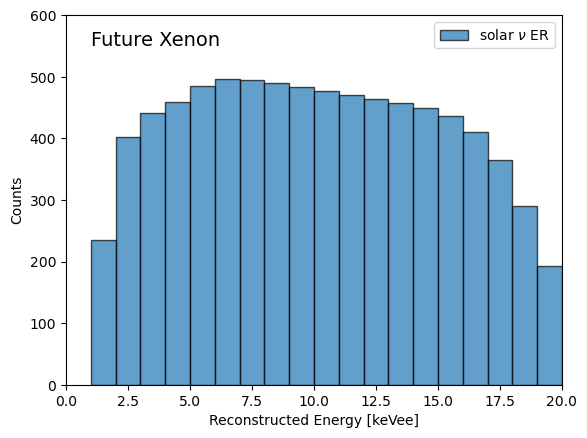

In [54]:
# Plotting histogram
plt.bar(bin_centers * 1e6, counts_er, width=bin_width*1e6, 
        edgecolor='black', alpha=0.7, align='center', label=r'${\rm solar}\ \nu$ ER')
plt.ylim(0,600)
plt.xlim(0.0,20.0)
plt.ylabel("Counts")
plt.xlabel(r'Reconstructed Energy [keVee]')
plt.text(1, 550, "Future Xenon", size=14)
plt.legend()

plt.show()